In [78]:
import numpy as np
import matplotlib.pyplot as plt

QR by Graham-Schmidt

In [79]:
def qr_gram(A):
    n, _ = A.shape
    Q = np.zeros_like(A)
    R = np.zeros_like(A)

    for k in range(n):
        v = np.zeros(n)
        suma = np.zeros(n)

        for i in range(k):
            R[i, k] = np.inner(Q[:, i], A[:, k])
            suma += R[i, k]*Q[:, i]
            
        v = A[:, k] - suma
        R[k, k] = np.linalg.norm(v, ord=2)
        Q[:, k] = v / R[k, k]

    return Q, R

In [80]:
def mgs(A):
    n, _ = A.shape
    Q = np.zeros_like(A)
    R = np.zeros_like(A)

    for k in range(n):
        v = A[:, k].copy()

        for i in range(k):
            R[i, k] = np.dot(Q[:, i], v)
            v = v - R[i, k] * Q[:, i]
            
        R[k, k] = np.linalg.norm(v, ord=2)
        Q[:, k] = v / R[k, k]

    return Q, R

In [81]:
for n in [3, 10, 50, 100, 300]:
    A = np.random.rand(n, n)
    I = np.identity(n)

    Q, R = qr_gram(A)
    Q_lib, R_lib = np.linalg.qr(A)

    print(f"\n---------------{n}-------------------\n")

    print("Reconstruction Error: ", np.linalg.norm(A - Q @ R, 2))
    print("Orthogonal Error: ", np.linalg.norm(I - Q @ Q.T, 2))
    print("Is upper triangular: ", np.allclose(R, np.triu(R)))
    print("Diff between numpy for Q: ", np.linalg.norm(Q - Q_lib, ord = 'fro'))
    print("Diff between numpy for R: ", np.linalg.norm(R - R_lib, ord = 'fro'))


---------------3-------------------

Reconstruction Error:  1.1102230246251565e-16
Orthogonal Error:  4.211709189936804e-15
Is upper triangular:  True
Diff between numpy for Q:  3.464101615137755
Diff between numpy for R:  3.6256270671207425

---------------10-------------------

Reconstruction Error:  2.4953405808980615e-16
Orthogonal Error:  5.828141086997575e-14
Is upper triangular:  True
Diff between numpy for Q:  3.4641016151377544
Diff between numpy for R:  9.748723771545869

---------------50-------------------

Reconstruction Error:  1.1757219509413003e-15
Orthogonal Error:  9.164898005991194e-13
Is upper triangular:  True
Diff between numpy for Q:  9.797958971132719
Diff between numpy for R:  52.43570159184387

---------------100-------------------

Reconstruction Error:  1.9522839831332643e-15
Orthogonal Error:  5.002022346589927e-11
Is upper triangular:  True
Diff between numpy for Q:  14.142135623730953
Diff between numpy for R:  105.12229658085224

---------------300-----

Generate Matrixes with given cond

In [82]:
def gen_matrix(p):
    U, _ = np.linalg.qr(np.random.randn(8, 8))
    V, _ = np.linalg.qr(np.random.randn(8, 8))

    diagonal = np.logspace(0, -p, 8)
    sigma = np.diag(diagonal)

    return U @ sigma @ V.T, diagonal[0] / diagonal[7]

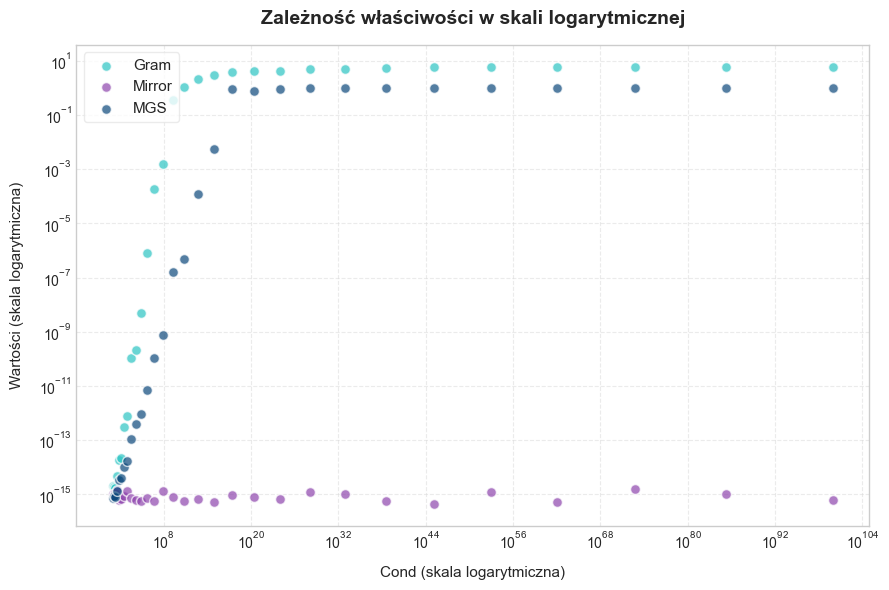

In [85]:
ps = np.logspace(start=0, stop=2, num=30)

gram = []
mirror = []
m = []
cond = []

for p in ps:
    A, c = gen_matrix(p)
    I = np.identity(8)

    cond.append(c)

    Q, R = qr_gram(A)
    gram.append(np.linalg.norm(I - Q @ Q.T, ord = 2))

    Q_m, R_m = mgs(A)
    m.append(np.linalg.norm(I - Q_m @ Q_m.T, ord = 2))

    Q_lib, R_lib = np.linalg.qr(A)
    mirror.append(np.linalg.norm(I - Q_lib @ Q_lib.T, ord = 2))


########################################################################
#                       Some Visualization Part                        #
########################################################################

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6), dpi=100)

ax.scatter(cond, gram, color='#2bc4c3', alpha=0.7, edgecolors='w', s=50, label='Gram')
ax.scatter(cond, mirror, color='#8e44ad', alpha=0.7, edgecolors='w', s=50, label='Mirror')
ax.scatter(cond, m, color="#0b477b", alpha=0.7, edgecolors='w', s=50, label='MGS')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('Zależność właściwości w skali logarytmicznej', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Cond (skala logarytmiczna)', fontsize=11, labelpad=10)
ax.set_ylabel('Wartości (skala logarytmiczna)', fontsize=11, labelpad=10)

ax.grid(True, which="both", ls="--", color='0.85', alpha=0.5)

ax.legend(frameon=True, facecolor='white', edgecolor='0.9', fontsize=11, loc='upper left')

plt.tight_layout()

plt.show()